In [3]:
!ls
!ls SpamBase/

Assign4.ipynb  SpamBase
spambase_csv.csv


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Loading and basic data exploration

In [17]:
def load_dataset(filepath,column_names=None,seperator=","):
    df=pd.read_csv(filepath,names=column_names,sep=seperator)
    df.columns = df.columns.str.strip()
    return df

def dataset_info(df):
    print("-" * 50)
    print("DATASET INFORMATION")
    print("-"*50)

    print("\n Shape: ",df.shape)
    print("\nColumns: ")
    print(df.columns.tolist())

    print("\nData Types: ")
    print(df.dtypes)

    print("\nMemory information")
    df.info()

    print("First 5 elements")
    print(df.head())
def missing_values(df):
    missing=df.isnull().sum()
    percent=(missing/len(df) )*100

    result=pd.DataFrame(
    {"missing":missing,
    "percent":percent
    })

    print(result)

    if (missing.sum() ==0):
        print("There is no missing value!")
    else:
        print("\033[31mMissing Values detected\033[0m")
    return result

def duplicate_info(df):
    duplicates = df.duplicated().sum()
    print("\nThe duplicate rows are : ",duplicates);

    if(duplicates ==0):
        print("No duplicates detected!")
    else:
        print("\033[31mDuplicates are detected\033[0m")

    return duplicates

def summary_statistics(df):
    print("\nSummary statsitics")
    print(df.describe())

   

In [33]:
def basic_eda(filepath,column_names=None,separator=",",):

    
    df = load_dataset(
        filepath,
        column_names=column_names,
        seperator=separator
    )

    print("\nLoading dataset completed\n")

    dataset_info(df)
    missing_values(df)
    duplicate_info(df)
    summary_statistics(df)

    return df
def class_distribution(df,target_column):
    print("\nClass Distribution")

    counts=df[target_column].value_counts()
    plot=counts.plot(kind="bar")
    plt.xlabel(target_column)
    plt.ylabel("Count")
    plt.title(f"Class Distribution of {target_column}")

    for container in plot.containers:
        plot.bar_label(container)
    plt.show()


In [34]:
df=basic_eda("data//spambase_csv.csv")
print(df)


Loading dataset completed

--------------------------------------------------
DATASET INFORMATION
--------------------------------------------------

 Shape:  (4601, 58)

Columns: 
['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_p


Class Distribution


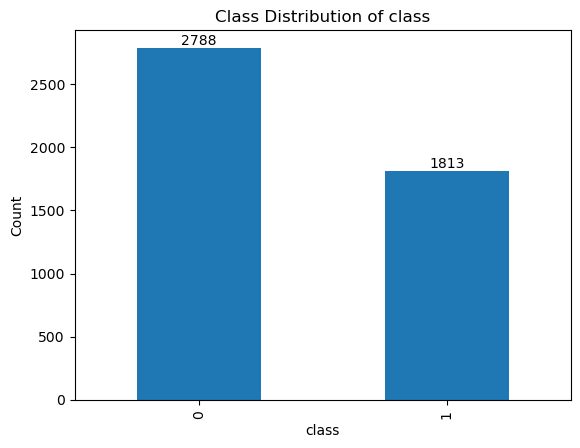

In [35]:
class_distribution(df,"class")

# Preprocessing The Data - using simpleimputer to handle missing data 
# Standardized Using Standard Scaler
# Split into train,test by train

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

def preprocess_data(df,target_col,test_size=0.2,random_state=42,impute_strategy="median"):
    X = df.drop(columns=[target_col])
    Y = df[target_col]

    x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=test_size,
    random_state=42,stratify=Y)

    imputer=SimpleImputer(strategy=impute_strategy)

    x_train = imputer.fit_transform(x_train)
    x_test = imputer.transform(x_test)

    scaler = StandardScaler()

    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)

    return x_train,x_test,y_train,y_test

In [23]:
x_train,x_test,y_train,y_test = preprocess_data(df,target_col="class")

# Baseline Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
def train_baseLogisticRegresion(x_train,x_test,y_train,y_test):
    lr_model = LogisticRegression(random_state=42)
    lr_model.fit(x_train,y_train)